In [1]:
!pip install -Uq pymcel

In [2]:
!pip install -Uq montu

In [3]:
!pip install -Uq rebound 

  error: subprocess-exited-with-error
  
  × Building wheel for rebound (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      fatal: not a git repository (or any of the parent directories): .git
      <string>:91: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
      C:\Users\Equipo Hogar\AppData\Local\Temp\pip-build-env-h3f14x7g\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\Equipo Hogar\AppData\Local\Temp\pip-build-env-h3f14x7g\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Equipo Hogar\AppData\Local\Temp\pip-build-env-h3f14x7g\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              *********************************

# Aberración de la luz de las estrellas

In [4]:
import pymcel as pc
import montu as mn
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!
Running MontuPython version 0.10.0


1. ¿Qué voy a hacer?: experimento para estudiar el cambio de posición de las estrellas debido a la aberración. Poner a prueba la fórmula general de aberración, es decir la que relaciona $\vec{n}'$ con $\vec{n}$

2. ¿Qué necesito para hacerlo?

Velocidad de la Tierra

In [5]:
tabla, jd, X = pc.consulta_horizons(
    id='399',
    location='@0',
    epochs='2025-03-24 15:40:00'
)
v_tierra = X[3:]
v_tierra

array([ 1.54361812e+03, -2.98426205e+04,  8.27267631e-01])

Saquemos ahora el beta de la estrella

In [6]:
beta_vec = -v_tierra / pc.constantes.c
beta = np.linalg.norm(beta_vec)
beta_vec, beta

(array([-5.14895583e-06,  9.95442672e-05, -2.75946779e-09]),
 np.float64(9.9677343879579e-05))

In [7]:
gamma = 1 / np.sqrt(1 - beta**2)

In [8]:
allstars = mn.Stars()

Loading stellar catalogue montu_stellar_catalogue_v38.csv


In [9]:
star = allstars.get_stars(ProperName='Aldebaran')
star

1 star(s):
|    |   MN |    HD |   HR |   HIP | Gl        | Name      | OtherDesignations                                                                     | ProperName   | Bayer   | Flamsteed   | Constellation   |   RAJ2000 |   DecJ2000 |   GalLonJ2000 |   GalLatJ2000 |   pmRA |   pmDec |   RadVel |   Distance |   Vmag |   Vmag_min |   Vmag_max |   B-V | SpType   |   Luminosity |   XJ2000 |   YJ2000 |   ZJ2000 |   VXJ2000 |   VYJ2000 |   VZJ2000 |   Primary | MultipleID   |   IsMultiple |   IsVariable |
|----|------|-------|------|-------|-----------|-----------|---------------------------------------------------------------------------------------|--------------|---------|-------------|-----------------|-----------|------------|---------------|---------------|--------|---------|----------|------------|--------|------------|------------|-------|----------|--------------|----------|----------|----------|-----------|-----------|-----------|-----------|--------------|--------------|---

In [11]:
ra = np.array(star.data.RAJ2000)[0]
dec = np.array(star.data.DecJ2000)[0]
ra, dec

(np.float64(4.598677), np.float64(16.509301))

In [12]:
mn.Util.dec2hex(ra), mn.Util.dec2hex(dec)

('04:35:55.237', '16:30:33.484')

Necesito $\vec{n}'$, un vector unitario

In [24]:
import spiceypy as spy
deg = np.pi / 180
rad = 180 / np.pi

In [18]:
nprima_equ = spy.latrec(1, ra*15*deg, dec*deg)
nprima_equ

array([0.34390374, 0.89497322, 0.28417099])

nprima está en el sistema ecuatorial absoluto, debo transformarlo al sistema eclíptico de coordenadas:

In [16]:
Requ2ecl = spy.pxform('J2000', 'ECLIPJ2000', 0) # 0 es num de segundos desde J2000
Requ2ecl

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.91748206,  0.39777716],
       [ 0.        , -0.39777716,  0.91748206]])

In [17]:
np.cos(23.5*deg), np.sin(23.5*deg)

(np.float64(0.917060074385124), np.float64(0.3987490689252462))

Obtenida la matriz de rotación puedo convertir el vector

In [19]:
nprima_ecl = spy.mxv(Requ2ecl, nprima_equ)
nprima_ecl

array([ 0.34390374,  0.9341586 , -0.09527812])

In [22]:
n = (nprima_ecl + ((gamma - 1)/beta**2 * beta_vec@nprima_ecl + gamma) * beta_vec) / \
    (gamma * (1 + beta_vec@nprima_ecl))
nprima_ecl, n


(array([ 0.34390374,  0.9341586 , -0.09527812]),
 array([ 0.34386722,  0.93417293, -0.09526943]))

El ángulo entre estos dos vectores es la aberración $\alpha$:

In [26]:
alpha = np.arccos(n @ nprima_ecl / (np.linalg.norm(n) * np.linalg.norm(nprima_ecl)))
alpha, alpha*rad, alpha*3600*rad

(np.float64(4.017960444565865e-05),
 np.float64(0.0023021217572413203),
 np.float64(8.287638326068754))

In [28]:
print(f'La aberración de Aldebaran es de {alpha*3600*rad:.2f} segundos de arco')

La aberración de Aldebaran es de 8.29 segundos de arco


Calcular la ascensión recta y declinación después de la aberración

In [30]:
n_equ = spy.mxv(spy.invert(Requ2ecl), n)
n_equ

array([0.34386722, 0.89498291, 0.28418466])

Lo convierto a coordenadas esféricas (astronómicas)

In [35]:
r, lon, lat = spy.reclat(n_equ)
ra_aberrada = lon * rad / 15
dec_aberrada = lat * rad

print(mn.Util.dec2hex(ra), mn.Util.dec2hex(dec))
print('Coordenadas afectadas por aberración:')
print(mn.Util.dec2hex(ra_aberrada), mn.Util.dec2hex(dec_aberrada))

04:35:55.237 16:30:33.484
Coordenadas afectadas por aberración:
04:35:55.776 16:30:36.425


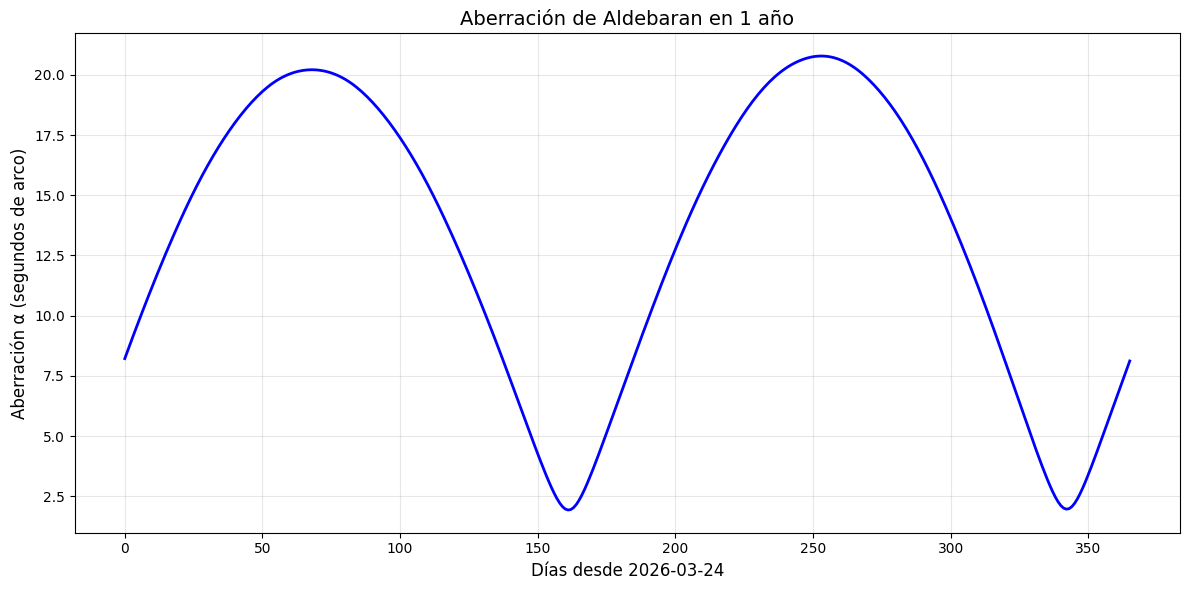

Aberración mínima: 1.9341 segundos de arco
Aberración máxima: 20.7779 segundos de arco
Variación: 18.8438 segundos de arco


In [29]:
import datetime
from datetime import timedelta
from scipy.interpolate import interp1d

# Crear array de 12 fechas (una por mes durante 1 año)
fecha_inicio = datetime.datetime(2026, 3, 24)
meses = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 365])
fechas = [fecha_inicio + timedelta(days=int(d)) for d in meses]

alpha_array_mensual = []
print("Calculando aberración mensual...")

for i, fecha in enumerate(fechas):
    print(f"  Mes {i+1}: {fecha.strftime('%Y-%m-%d')}")
    tabla_i, jd_i, X_i = pc.consulta_horizons(id='399', location='@0', epochs=fecha.strftime('%Y-%m-%d'))
    v_tierra_i = X_i[3:]
    beta_vec_i = -v_tierra_i / pc.constantes.c
    beta_i = np.linalg.norm(beta_vec_i)
    gamma_i = 1 / np.sqrt(1 - beta_i**2)
    
    n_i = (nprima_ecl + ((gamma_i - 1)/beta_i**2 * beta_vec_i@nprima_ecl + gamma_i) * beta_vec_i) / \
          (gamma_i * (1 + beta_vec_i@nprima_ecl))
    
    alpha_i = np.arccos(n_i @ nprima_ecl / (np.linalg.norm(n_i) * np.linalg.norm(nprima_ecl)))
    alpha_array_mensual.append(alpha_i * 3600 * rad)

alpha_array_mensual = np.array(alpha_array_mensual)

# Interpolar
f_interp = interp1d(meses, alpha_array_mensual, kind='cubic')
dias = np.linspace(0, 365, 366)
alpha_dias = f_interp(dias)

# Gráfico
plt.figure(figsize=(14, 7))
plt.plot(dias, alpha_dias, 'b-', linewidth=2.5, label='Interpolación')
plt.plot(meses, alpha_array_mensual, 'ro', markersize=8, label='Datos calculados')
plt.xlabel('Días desde 2026-03-24', fontsize=13)
plt.ylabel('Aberración α (segundos de arco)', fontsize=13)
plt.title('Variación de la Aberración de Aldebaran durante 1 año', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

print(f'\n=== RESULTADOS ===')
print(f'Aberración mínima: {alpha_dias.min():.6f} segundos de arco')
print(f'Aberración máxima: {alpha_dias.max():.6f} segundos de arco')
print(f'Variación total: {alpha_dias.max() - alpha_dias.min():.6f} segundos de arco')
print(f'Aberración media: {alpha_dias.mean():.6f} segundos de arco')